In [1]:
# Standard library
import os
import io
import ast

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Google Colab utilities
from google.colab import files

In [2]:
# Upload  file
uploaded = files.upload()
fname = next(iter(uploaded))
print("Uploaded:", fname)

Saving cleaned_comments.csv to cleaned_comments.csv
Uploaded: cleaned_comments.csv


In [3]:
# Load dataset & validation

if fname.lower().endswith('.csv'):
    df = pd.read_csv(fname)
elif fname.lower().endswith('.txt'):
    df = pd.read_table(fname)
else:
    raise Exception("Upload a .csv or .txt file named cleaned_comments.*")

print(f"My dataset contains {df.shape[0]} comments and {df.shape[1]} columns.")
display(df.head())

My dataset contains 963 comments and 8 columns.


,username,timestamp,likes,comment_text,cleaned_tokens,tok_len,char_len,word_len
0,heidierwin3546,2025-10-19T22:03:01Z,0,"This was good, but probably needs to be update...","['good', 'probably', 'need', 'updated', 'examp...",10,107,18
1,magdalenaojeda3315,2025-10-18T08:30:23Z,0,This is amazing!,['amazing'],1,16,3
2,anadikulkarni5039,2025-10-14T11:22:03Z,0,Ngl this was just a giant Twilio advertisement.,"['ngl', 'giant', 'twilio', 'advertisement']",4,47,8
3,F8ferrari888,2025-10-11T00:32:33Z,0,Are you Mr Beasts&#39; father? lol. Why do you...,"['beast', 'father', 'lol', 'look', 'like', 'co...",11,115,23
4,FlexTransportationServicesLLC,2025-10-09T21:31:10Z,0,I would like to reach out to you. I have been ...,"['would', 'like', 'reach', 'brainstorming', 'w...",20,252,47


In [4]:
# Prepare text corpus
def join_tokens(x):
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list,tuple)):
                return " ".join(map(str, parsed))
        except Exception:
            pass
        return x
    elif isinstance(x, (list,tuple)):
        return " ".join(map(str,x))
    else:
        return str(x)

text_col = None
if 'cleaned_tokens' in df.columns:
    corpus = df['cleaned_tokens'].astype(str).apply(join_tokens).tolist()
    text_col = 'cleaned_tokens'
elif 'cleaned_text' in df.columns:
    corpus = df['cleaned_text'].astype(str).tolist()
    text_col = 'cleaned_text'
else:
    cands = [c for c in df.columns if 'text' in c.lower() or 'comment' in c.lower()]
    if cands:
        text_col = cands[0]
        corpus = df[text_col].astype(str).tolist()
    else:
        raise Exception("No usable text column found.")
print("Using text column:", text_col)

Using text column: cleaned_tokens


In [5]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(corpus)  # sparse matrix
print("TF-IDF shape:", X.shape)

TF-IDF shape: (963, 2000)


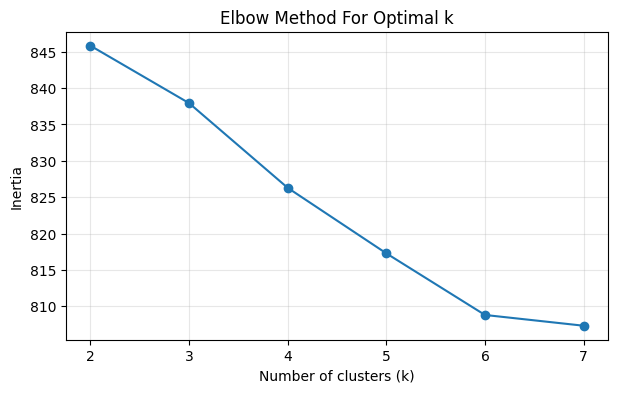

In [6]:
# Elbow plot for K
inertia = []
K = range(2,8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Run K-Means
optimal_k = 3 # <-- change this after inspecting the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
df['kmeans_label'] = kmeans_labels
print(f"KMeans done (k={optimal_k}). Cluster counts:")
print(df['kmeans_label'].value_counts())

KMeans done (k=3). Cluster counts:
kmeans_label
0    708
1    152
2    103
Name: count, dtype: int64


In [8]:
# Top terms for each K-Means cluster
terms = vectorizer.get_feature_names_out()
for i in range(optimal_k):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    top_terms = [terms[j] for j in top_idx]
    print(f"\nCluster {i} top terms:\n", ", ".join(top_terms))


Cluster 0 top terms:
 thank, video, thanks, quot, spotify, like, great, token, beast, amazing

Cluster 1 top terms:
 api, course, video, thank, best, good, spotify, really, great, apis

Cluster 2 top terms:
 zgxjrw, wxsd, http, amp, com, www, href, youtube, watch, quot


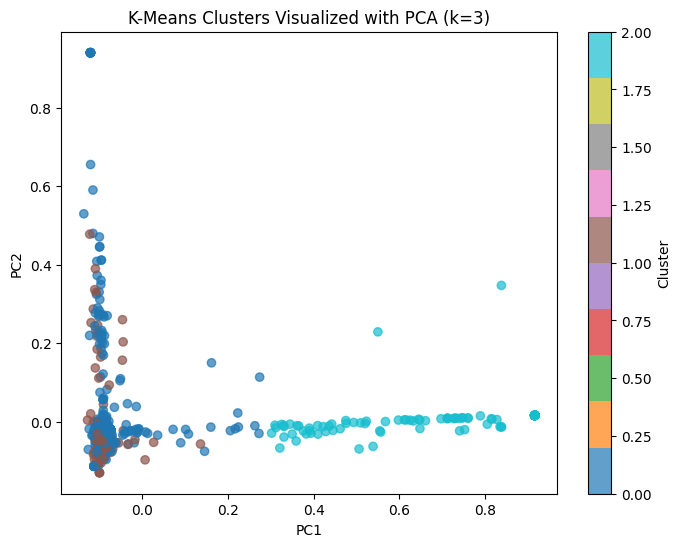

In [9]:
# Visualize K-Means with PCA

# Convert sparse TF-IDF to dense for PCA (OK if dataset is not huge)
X_dense = X.toarray()

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

# Visualize K-Means clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=df['kmeans_label'],
            cmap='tab10',
            alpha=0.7)
plt.title(f'K-Means Clusters Visualized with PCA (k={optimal_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()

In [10]:
# Scale TF-IDF for DBSCAN

X_scaled = StandardScaler(with_mean=False).fit_transform(X)
print("Scaled TF-IDF ready for DBSCAN.")

results = []
for eps in [0.3, 0.5, 0.7]:
    db = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    results.append({
        'eps': eps,
        'min_samples': 5,
        'clusters': n_clusters,
        'noise_points': n_noise
    })
    print(f"eps={eps}: clusters={n_clusters}, noise_points={n_noise}")

import pandas as pd
display(pd.DataFrame(results))

Scaled TF-IDF ready for DBSCAN.
eps=0.3: clusters=4, noise_points=867
eps=0.5: clusters=4, noise_points=867
eps=0.7: clusters=4, noise_points=867


,eps,min_samples,clusters,noise_points
0,0.3,5,4,867
1,0.5,5,4,867
2,0.7,5,4,867


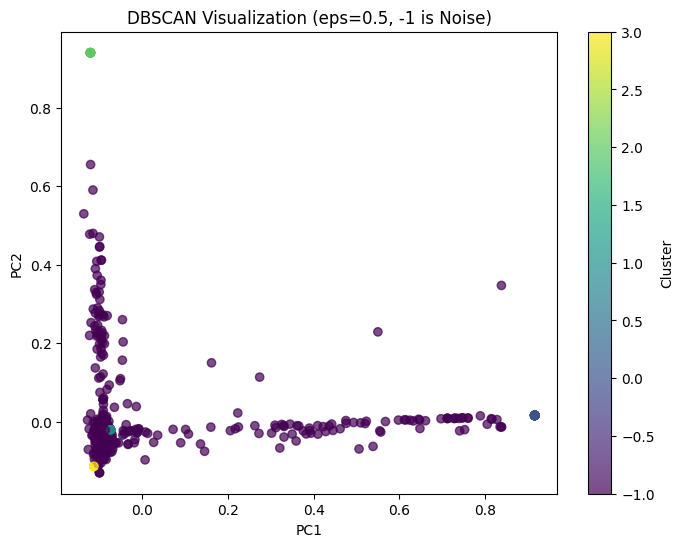


DBSCAN label -1 (count: 867) — examples:


,cleaned_tokens,kmeans_label,dbscan_label
0,"['good', 'probably', 'need', 'updated', 'examp...",0,-1
1,['amazing'],0,-1
2,"['ngl', 'giant', 'twilio', 'advertisement']",0,-1
3,"['beast', 'father', 'lol', 'look', 'like', 'co...",0,-1
4,"['would', 'like', 'reach', 'brainstorming', 'w...",0,-1



DBSCAN label 0 (count: 32) — examples:


,cleaned_tokens,kmeans_label,dbscan_label
10,"['href', 'http', 'www', 'youtube', 'com', 'wat...",2,0
21,"['href', 'http', 'www', 'youtube', 'com', 'wat...",2,0
72,"['href', 'http', 'www', 'youtube', 'com', 'wat...",2,0
87,"['href', 'http', 'www', 'youtube', 'com', 'wat...",2,0
140,"['href', 'http', 'www', 'youtube', 'com', 'wat...",2,0



DBSCAN label 1 (count: 46) — examples:


,cleaned_tokens,kmeans_label,dbscan_label
19,['avichiii'],0,1
25,['found'],0,1
106,['unsee'],0,1
145,[],0,1
174,[],0,1



DBSCAN label 2 (count: 11) — examples:


,cleaned_tokens,kmeans_label,dbscan_label
49,['thank'],0,2
63,['thank'],0,2
127,"['thank', 'much']",0,2
388,['thank'],0,2
479,['thank'],0,2



DBSCAN label 3 (count: 7) — examples:


,cleaned_tokens,kmeans_label,dbscan_label
167,['thanks'],0,3
241,"['thanks', 'alot']",0,3
298,['thanks'],0,3
452,['thanks'],0,3
549,['thanks'],0,3


In [11]:
# Re-run DBSCAN

best_eps = 0.5  # <-- CHANGE THIS based on your own results

db_final = DBSCAN(eps=best_eps, min_samples=5, metric='euclidean')
db_labels = db_final.fit_predict(X_scaled)
df['dbscan_label'] = db_labels

# Reuse the same PCA projection (X_pca) computed in Cell 9
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=db_labels,
            cmap='viridis',
            alpha=0.7)
plt.title(f'DBSCAN Visualization (eps={best_eps}, -1 is Noise)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()

# Show sample comments per DBSCAN label
cols_show = [text_col]   # this becomes 'cleaned_tokens' in your case

for lab in sorted(set(db_labels)):
    cnt = (df['dbscan_label'] == lab).sum()
    print(f"\nDBSCAN label {lab} (count: {cnt}) — examples:")
    display(
        df[df['dbscan_label'] == lab].head(5)[[
            cols_show[0],      # cleaned text
            'kmeans_label',
            'dbscan_label'
        ]]
    )